In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread(r"C:\Projects\tivora\vto_mvp\notebooks\notebook_aids\sample01.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

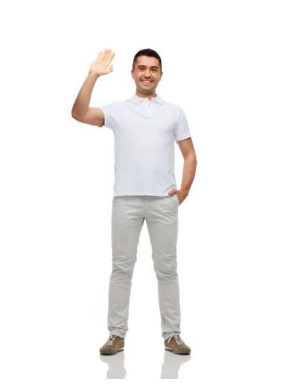

In [3]:
plt.imshow(img_rgb)
plt.axis("off")

In [4]:
import mediapipe as mp

In [5]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

In [6]:
with mp_pose.Pose(static_image_mode=True) as pose:
    results = pose.process(img_rgb)

c:\Users\Shiven\anaconda3\envs\tivora-vto\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

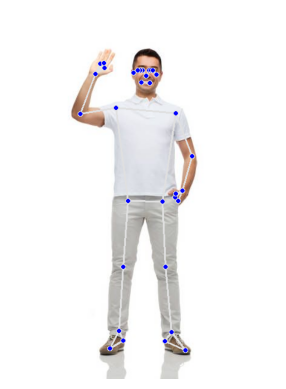

In [7]:
pose_img = img_rgb.copy()
if results.pose_landmarks:
    mp_drawing.draw_landmarks(
        pose_img,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS
    )
plt.imshow(pose_img)
plt.axis("off")

In [8]:
import numpy as np

In [9]:
def get_point(landmarks, idx, img_shape):
    h, w, _ = img_shape
    lm = landmarks[idx]
    return int(lm.x * w), int(lm.y * h)

landmarks = results.pose_landmarks.landmark

LEFT_SHOULDER = get_point(landmarks, mp_pose.PoseLandmark.LEFT_SHOULDER, img_rgb.shape)
RIGHT_SHOULDER = get_point(landmarks, mp_pose.PoseLandmark.RIGHT_SHOULDER, img_rgb.shape)
LEFT_HIP = get_point(landmarks, mp_pose.PoseLandmark.LEFT_HIP, img_rgb.shape)
RIGHT_HIP = get_point(landmarks, mp_pose.PoseLandmark.RIGHT_HIP, img_rgb.shape)

In [10]:
LEFT_SHOULDER, RIGHT_SHOULDER, LEFT_HIP, RIGHT_HIP

((274, 172), (175, 163), (252, 318), (195, 317))

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

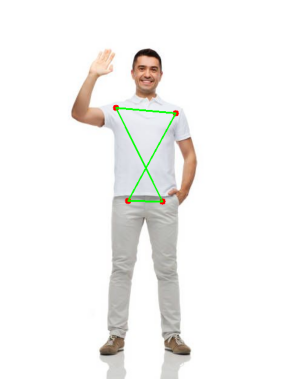

In [11]:
torso_img = img_rgb.copy()
for p in [LEFT_SHOULDER, RIGHT_SHOULDER, LEFT_HIP, RIGHT_HIP]:
    cv2.circle(torso_img, p, 5, (255, 0, 0), -1)

pts = np.array([LEFT_SHOULDER, RIGHT_SHOULDER, LEFT_HIP, RIGHT_HIP], np.int32)
cv2.polylines(torso_img, [pts], isClosed=True, color=(0,255,0), thickness=2)

plt.imshow(torso_img)
plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

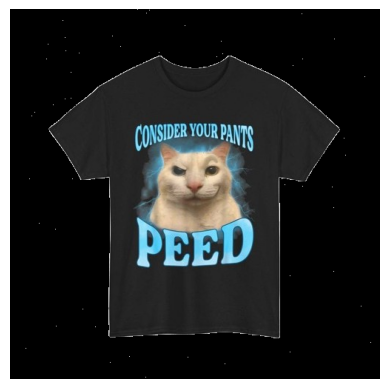

In [12]:
garment = cv2.imread(r"C:\Projects\tivora\vto_mvp\notebooks\notebook_aids\tshirt02.png")
garment_rgb = cv2.cvtColor(garment, cv2.COLOR_BGRA2RGBA)
plt.imshow(garment_rgb)
plt.axis("off")

In [13]:
import math

In [14]:
def distance(p1, p2):
    return math.dist(p1, p2)

user_shoulder_width = distance(LEFT_SHOULDER, RIGHT_SHOULDER)
user_shoulder_width

99.40824915468535

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

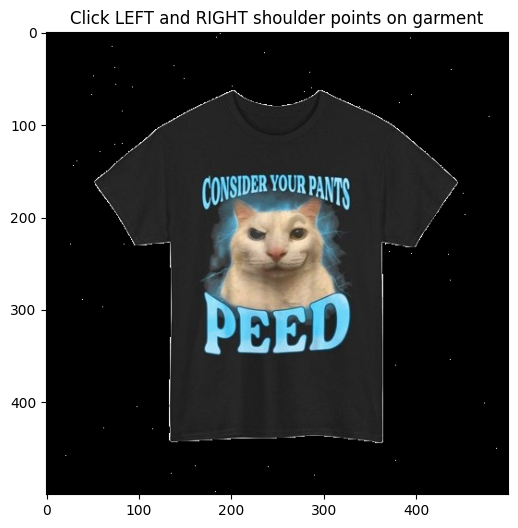

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(garment_rgb)
plt.title("Click LEFT and RIGHT shoulder points on garment")
plt.axis("on")
# coords = plt.ginput(2)
# coords

In [16]:
garment_left_shoulder  = (350, 100)
garment_right_shoulder = (150, 100)

In [17]:
garment_shoulder_width = distance(garment_left_shoulder, garment_right_shoulder)
garment_shoulder_width

200.0

In [18]:
scale_factor = user_shoulder_width / garment_shoulder_width
scale_factor

0.49704124577342673

(np.float64(-0.5), np.float64(247.5), np.float64(247.5), np.float64(-0.5))

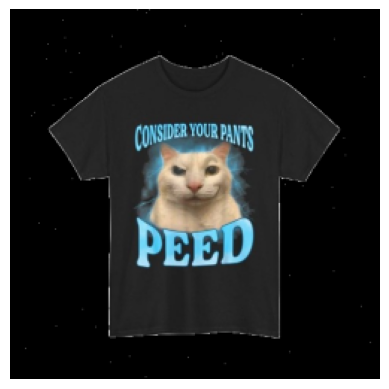

In [19]:
scaled_width = int(garment.shape[1] * scale_factor)
scaled_height = int(garment.shape[0] * scale_factor)
garment_scaled = cv2.resize(
    garment_rgb,
    (scaled_width, scaled_height),
    interpolation=cv2.INTER_AREA
)
plt.imshow(garment_scaled)
plt.axis("off")

In [20]:
dy = LEFT_SHOULDER[1] - RIGHT_SHOULDER[1]
dx = LEFT_SHOULDER[0] - RIGHT_SHOULDER[0]
rotation_angle = np.degrees(np.arctan2(dy, dx))
rotation_angle

np.float64(5.194428907734806)

(np.float64(-0.5), np.float64(247.5), np.float64(247.5), np.float64(-0.5))

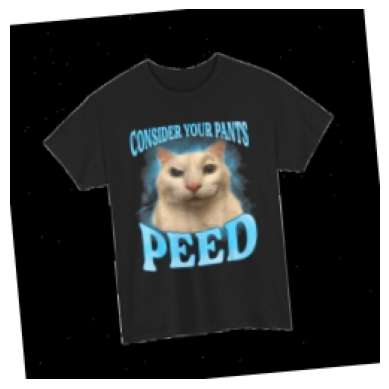

In [21]:
(h, w) = garment_scaled.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
garment_rotated = cv2.warpAffine(garment_scaled, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))
plt.imshow(garment_rotated)
plt.axis("off")

In [22]:
g_ls = np.array(garment_left_shoulder)
g_rs = np.array(garment_right_shoulder)

In [23]:
g_ls_scaled = g_ls * scale_factor
g_rs_scaled = g_rs * scale_factor

In [24]:
M = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
def apply_transform(point, M):
    x, y = point
    new_x = M[0,0]*x + M[0,1]*y + M[0,2]
    new_y = M[1,0]*x + M[1,1]*y + M[1,2]
    return np.array([new_x, new_y])

g_ls_transformed = apply_transform(g_ls_scaled, M)
g_rs_transformed = apply_transform(g_rs_scaled, M)

In [25]:
tx = LEFT_SHOULDER[0] - g_ls_transformed[0]
ty = LEFT_SHOULDER[1] - g_ls_transformed[1]
translation_vector = (tx, ty)
translation_vector

(np.float64(106.96719011126757), np.float64(126.51432509272297))

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

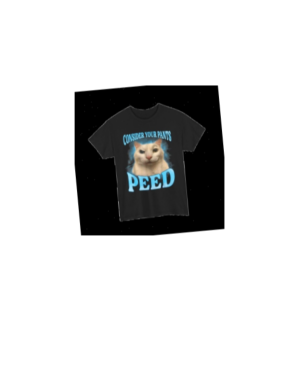

In [26]:
M_translate = np.float32([[1,0,tx],
[0,1,ty]])
garment_aligned = cv2.warpAffine(
    garment_rotated,
    M_translate,
    (img_rgb.shape[1], img_rgb.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0,0,0,0)
)
plt.imshow(garment_aligned)
plt.axis("off")

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

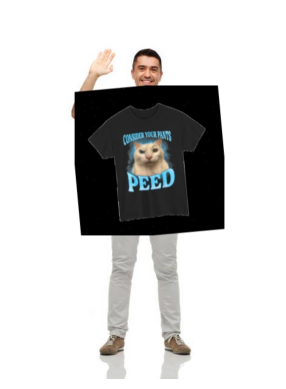

In [27]:
person_rgba = np.dstack([img_rgb, np.full((img_rgb.shape[0], img_rgb.shape[1]), 255, dtype=np.uint8)])
g_b, g_g, g_r, g_a = cv2.split(garment_aligned)
alpha = g_a.astype(float)/255.0
alpha_inv = 1 - alpha
output = person_rgba.copy()
for c in range(3):
    output[:,:,c] = (alpha*garment_aligned[:,:,c]+alpha_inv*output[:,:,c])
plt.imshow(output)
plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

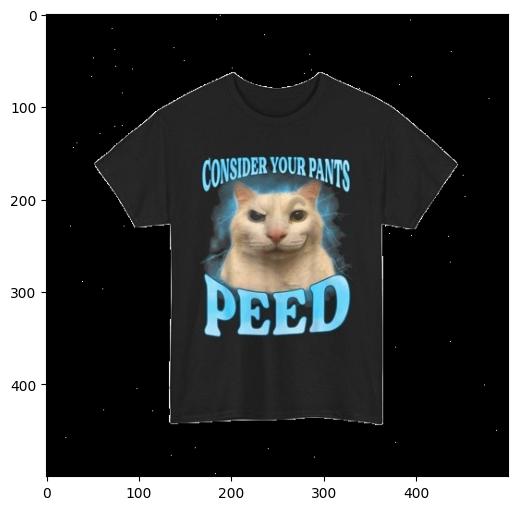

In [28]:
plt.figure(figsize=(6,6))
plt.imshow(garment_rgb)
plt.axis("on")

In [29]:
# garment_points = np.array([
#     (350, 100),  # left shoulder
#     (150, 100),  # right shoulder
#     (325, 155),  # left chest
#     (175, 155),  # right chest
#     (250, 300),  # torso mid
#     (350, 430),  # left waist
#     (150, 425),  # right waist
# ], dtype=np.float32)
# garment_points = np.array([
#     (130, 110),   # 1. Left Shoulder
#     (370, 110),   # 2. Right Shoulder
#     (160, 230),   # 3. Left Chest
#     (340, 230),   # 4. Right Chest
#     (170, 360),   # 5. Left Waist
#     (330, 360)    # 6. Right Waist
# ], dtype=np.float32)

garment_points = np.array([
    # SHOULDERS (top corners of sleeves)
    (95, 105),    # Left sleeve top
    (405, 105),   # Right sleeve top

    # SHOULDERS (neck area)
    (200, 105),   # Left neck
    (300, 105),   # Right neck

    # CHEST (left and right)
    (150, 220),   # Left chest
    (350, 220),   # Right chest

    # MID-TORSO side points
    (135, 300),   # Left mid torso
    (365, 300),   # Right mid torso

    # WAIST / HEM
    (155, 390),   # Left waist
    (345, 390)    # Right waist
], dtype=np.float32)



In [30]:
garment_points_scaled = garment_points * scale_factor
garment_points_rotated = np.array([apply_transform(p, M) for p in garment_points_scaled])
garment_points_transformed = garment_points_rotated + np.array([tx, ty])

In [31]:
LS = np.array(LEFT_SHOULDER)
RS = np.array(RIGHT_SHOULDER)
LH = np.array(LEFT_HIP)
RH = np.array(RIGHT_HIP)

chest_mid_L = (2*LS + LH) / 3
chest_mid_R = (2*RS + RH) / 3

mid_torso_L = (LS + LH) / 2
mid_torso_R = (RS + RH) / 2

user_points = np.array([
    LS,            # left shoulder outer
    RS,            # right shoulder outer
    (LS + RS)/2,   # left neck (approx)
    (LS + RS)/2,   # right neck (same)
    chest_mid_L,
    chest_mid_R,
    mid_torso_L,
    mid_torso_R,
    LH,
    RH
], dtype=np.float32)



In [32]:
from skimage.transform import PiecewiseAffineTransform, warp

In [33]:
print("user_points shape:", user_points.shape)
print("garment_points shape:", garment_points.shape)
print("garment_points_scaled shape:", garment_points_scaled.shape)
print("garment_points_rotated shape:", garment_points_rotated.shape)
print("garment_points_transformed shape:", garment_points_transformed.shape)

print("user_points:\n", user_points)
print("garment_points_transformed:\n", garment_points_transformed)


user_points shape: (10, 2)
garment_points shape: (10, 2)
garment_points_scaled shape: (10, 2)
garment_points_rotated shape: (10, 2)
garment_points_transformed shape: (10, 2)
user_points:
 [[274.      172.     ]
 [175.      163.     ]
 [224.5     167.5    ]
 [224.5     167.5    ]
 [266.66666 220.66667]
 [181.66667 214.33333]
 [263.      245.     ]
 [185.      240.     ]
 [252.      318.     ]
 [195.      317.     ]]
garment_points_transformed:
 [[147.99999952 185.95000029]
 [301.45000749 171.99999957]
 [199.97499977 181.22500027]
 [249.47500724 176.72499959]
 [180.40000372 240.40000091]
 [279.39999587 231.40000163]
 [176.57500315 280.67500699]
 [290.42500513 270.32500681]
 [190.52500387 324.32499839]
 [284.57500287 315.77499848]]


In [34]:
tps = PiecewiseAffineTransform()
tps.estimate(user_points, garment_points_transformed)
warped_garment = warp(garment_aligned, tps, output_shape=img_rgb.shape[:2], mode='constant', cval=0)

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

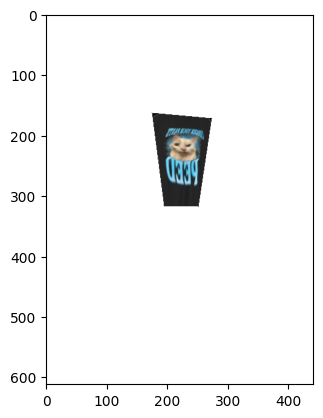

In [35]:
plt.imshow(warped_garment)
plt.axis("on")


In [36]:
warped_garment_8u = (warped_garment * 255).astype(np.uint8)

In [37]:
if warped_garment_8u.shape[2] == 3:
    alpha_channel = np.ones_like(warped_garment_8u[:,:,0]) * 255
    warped_garment_8u = np.dstack([warped_garment_8u, alpha_channel])

(np.float64(-0.5), np.float64(441.5), np.float64(611.5), np.float64(-0.5))

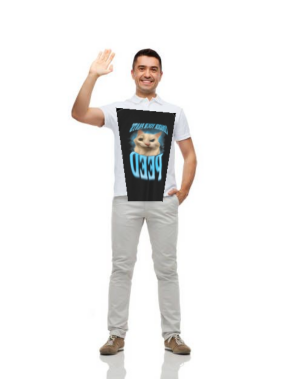

In [38]:
person_rgba = np.dstack([img_rgb, np.full((img_rgb.shape[0], img_rgb.shape[1]), 255, dtype=np.uint8)])

g_b, g_g, g_r, g_a = cv2.split(warped_garment_8u)

alpha = g_a.astype(float) / 255.0
alpha_inv = 1 - alpha

output = person_rgba.copy()

for c in range(3):
    output[:,:,c] = alpha * warped_garment_8u[:,:,c] + alpha_inv * output[:,:,c]

plt.imshow(output)
plt.axis("off")
